In [3]:
import numpy as np
from matplotlib import pyplot as plt 
import cv2

## Lab 3: Image clustering and superpixels

In this lab we are going to explore image clustering and superpixels segmentation. You will be required to complete the following tasks:

1. Implement k-means clustering to assign each pixel of an image to one of K distinct clusters, using colour similarity to determine assignment.
2. Modify your k-means clustering to find superpixels by assigning each pixel of the image to one of K distinct clusters, using both colour and location similarity to determine assignment.
3. Use superpixels to propose regions of interest in the image (we will learn about neural networks that use this information in week 11). 
4. Write a brief report (max 600 words) discussing explaining your implementation and results. Explain your reasoning by referencing the intermediate result figures you generated. 

You may use numpy and matplotlib and opencv for image loading.

### Academic integrity

Every lab submission will be screened for any collusion and/or plagiarism. Breaches of academic integrity will be investigated thoroughly and may result in a zero for the assessment along with interviews with the plagiarism officers at Monash University.

### Late submissions

The default late submission university penalty will apply.

### Lab Instructions and the Use of Generative AI

You may not use any built-in opencv functions for this lab, other than those used for loading/ saving an image, extracting and matching keypoints, and
computing homographies.
* You may use NumPy for array handling, and vectorizing your code (reducing
the number of for-loops) is encouraged.
* You should use Matplotlib to display images and any intermediate results.
* You may use generative AI.

### Grading
Each lab is worth 8%, and there are a number of sections and tasks with their own weighting. A task is only considered complete if you can demonstrate a working program and show an understanding of the underlying concepts. Note that later tasks should reuse code from earlier tasks.

Masks will be provided based on the correctness of the code, the quality of your results, comments indicating you understand your work, and a discussion of tasks provided at the end of the notebook. 

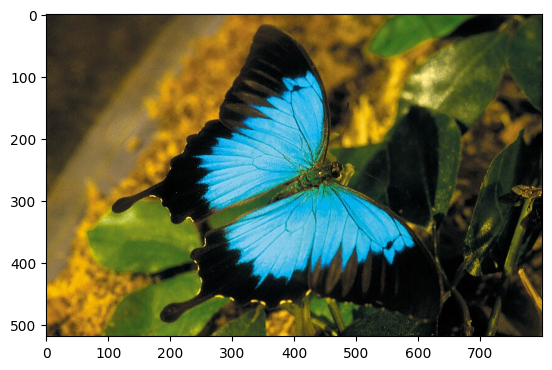

In [25]:
# Load and display image for testing
im = cv2.imread('CSIRO_ScienceImage_3831_Ulysses_Butterfly.jpg')/255.0
plt.imshow(im[:,:,[2,1,0]])
plt.show()

### Task 1: Implement K-means from first principles: colour similarity

Fill in the function below to implement the following steps. Your function should accept an image, a variable storing the number of iterations to repeat k-means for, the number of clusters K.
1. Flatten the image into an Nx3 vector of pixels (num pixels x r,g,b colour of pixel)
2. Select K random colour centroids
3. Repeat for n iterations:
   1. Assign each pixel in the vector to a cluster and store the index corresponding to this in a numpy array
   2. Update the centroid locations using the new cluster assignments
   3. Save the total loss at each iteration
4. Convert the cluster index array back into a 2D array the same size as the image, where each pixel contains the corresponding cluster index
5. Create a new quantised image, where each pixel is coloured according to the centroid corresponding to a given cluster index.
6. Return the loss, cluster index image and quantised image
7. Test your function on the sample image provided, and select an appropriate number of iterations 
8. Display the results for a number of choices of K. Use the returned losses to select an appropriate value for K 

In [27]:
def kmeans(im, iters=10, K=3, plot=False):
    
    # Kmeans is stochastic, so we will fix the seed of the random number generator to ensure each iteration starts with the same centroid initialisation
    seed = 42
    np.random.seed(seed)
    
    H, W, C = im.shape
    
    # Flatten image into Nx3 vector of pixels
    pixels = im.reshape(-1, C)  # shape: (N, 3)
    N = pixels.shape[0]
    
    # Select K random colour centroids from existing pixels
    idx = np.random.choice(N, K, replace=False)
    centroids = pixels[idx].copy()  # shape: (K, 3)
    
    losses = []
    
    for j in range(1, iters):
        
        # Assign pixels to clusters: compute squared distances to each centroid
        # pixels: (N,3), centroids: (K,3) -> dists: (N,K)
        dists = np.sum((pixels[:, None, :] - centroids[None, :, :]) ** 2, axis=2)
        cluster_indices = np.argmin(dists, axis=1)  # shape: (N,)
        
        # Update centroid locations using new cluster assignments
        new_centroids = np.zeros_like(centroids)
        for k in range(K):
            mask = cluster_indices == k
            if mask.sum() > 0:
                new_centroids[k] = pixels[mask].mean(axis=0)
            else:
                new_centroids[k] = centroids[k]  # keep old centroid if empty
        centroids = new_centroids
        
        # Store the current loss (sum of squared distances to assigned centroid)
        assigned_centroids = centroids[cluster_indices]  # (N, 3)
        loss = np.sum((pixels - assigned_centroids) ** 2)
        losses.append(loss)
        
        # Convert cluster indices to a 2D image
        cluster_idx_image = cluster_indices.reshape(H, W)
        
        # Create a quantised image: replace each pixel with its centroid colour
        quantised_image = centroids[cluster_indices].reshape(H, W, C)
        
        # You may want to visualise the current progress of kmeans for debugging purposes
        if plot:
            plt.subplot(1,2,1)
            plt.imshow(cluster_idx_image)
            plt.subplot(1,2,2)
            plt.imshow(quantised_image)
            plt.show()
    
    return losses, cluster_idx_image, quantised_image


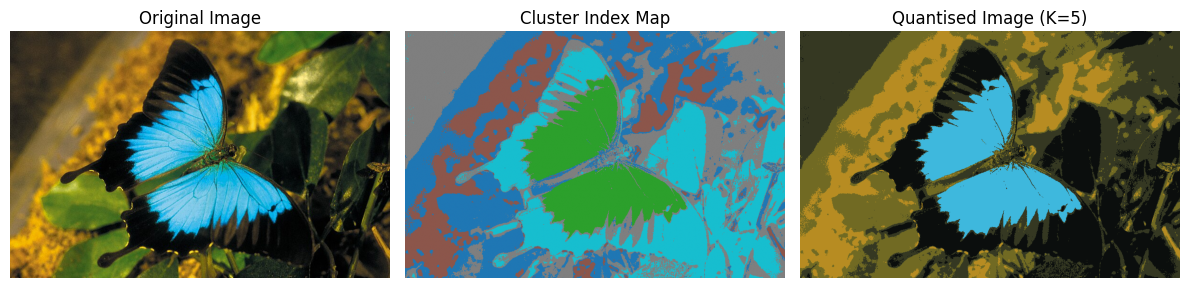

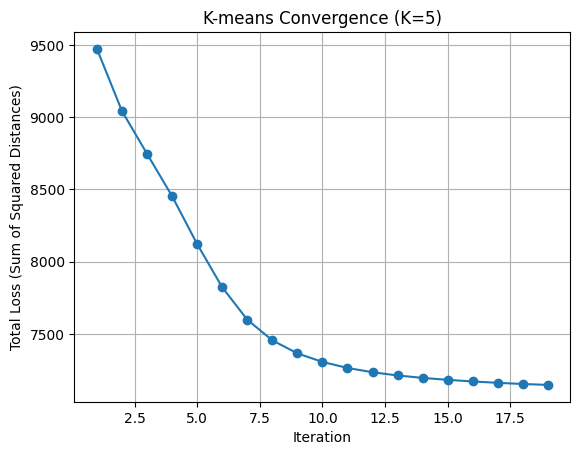

In [28]:
# Test your function using the image provided
losses, cluster_idx_image, quantised_image = kmeans(im, iters=20, K=5, plot=False)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(im[:, :, [2, 1, 0]])
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Cluster Index Map')
plt.imshow(cluster_idx_image, cmap='tab10')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Quantised Image (K=5)')
plt.imshow(quantised_image[:, :, [2, 1, 0]])
plt.axis('off')

plt.tight_layout()
plt.show()

plt.figure()
plt.plot(range(1, len(losses) + 1), losses, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Total Loss (Sum of Squared Distances)')
plt.title('K-means Convergence (K=5)')
plt.grid(True)
plt.show()


K=2, final loss=38413.2131
K=3, final loss=13771.4765
K=5, final loss=7146.3095
K=8, final loss=4340.5007
K=12, final loss=3226.5643
K=16, final loss=2439.3883


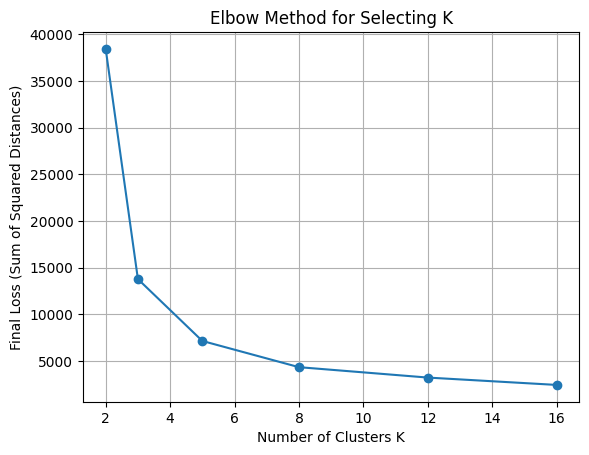

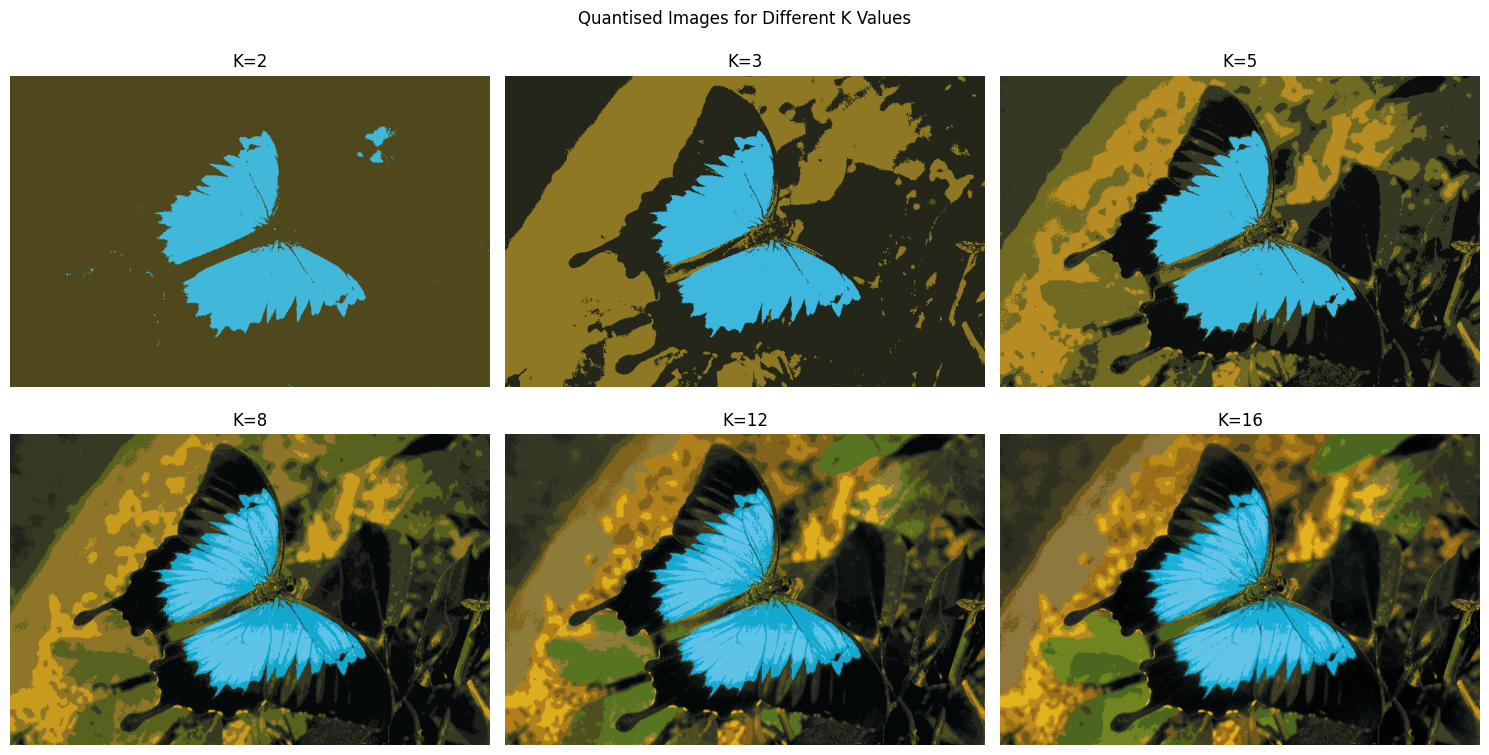

In [29]:
# Select an appropriate value for K using the elbow method
k_values = [2, 3, 5, 8, 12, 16]
final_losses = []

for K in k_values:
    losses, _, _ = kmeans(im, iters=20, K=K)
    final_losses.append(losses[-1])
    print(f'K={K}, final loss={losses[-1]:.4f}')

# Plot elbow curve
plt.figure()
plt.plot(k_values, final_losses, marker='o')
plt.xlabel('Number of Clusters K')
plt.ylabel('Final Loss (Sum of Squared Distances)')
plt.title('Elbow Method for Selecting K')
plt.grid(True)
plt.show()

# Visualise quantised images for several K values
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, K in zip(axes.flat, k_values):
    _, _, q_im = kmeans(im, iters=20, K=K)
    ax.imshow(q_im[:, :, [2, 1, 0]])
    ax.set_title(f'K={K}')
    ax.axis('off')
plt.suptitle('Quantised Images for Different K Values')
plt.tight_layout()
plt.show()


### Task 2: Modify K-means to cluster based on colour similarity and pixel location and extract superpixels

1. Modify the k_means function above to segment based on colour and pixel location, so that you extract superpixels.

2. Test your implementation by clustering the image into 50 superpixels.

3. Select an appropriate pixel coordinate scaling factor so that you trade-off incorporating colour information into the clustering, while ensuring superpixel continuity (all pixels in a superpixel must remain connected).

In [30]:
def kmeans_superpixels(im, iters=10, K=50, alpha=None, plot=False):
    seed = 42
    np.random.seed(seed)
    
    H, W, C = im.shape
    N = H * W
    
    # Build pixel coordinate grid: ys = row, xs = column
    ys, xs = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
    coords = np.stack([ys, xs], axis=-1).astype(np.float64)  # (H, W, 2)
    
    # Default alpha: scale so spatial extent of one superpixel is ~unit length
    if alpha is None:
        S = np.sqrt(N / K)        # expected superpixel side
        alpha = 1.0 / S
    
    # Concatenate colour and scaled coords into 5D features
    features = np.concatenate([im, alpha * coords], axis=-1)   # (H, W, 5)
    pixels   = features.reshape(-1, C + 2)                     # (N, 5)
    
    # Initialise centroids from random pixels
    idx = np.random.choice(N, K, replace=False)
    centroids = pixels[idx].copy()                             # (K, 5)
    
    losses = []
    
    for j in range(1, iters):
        # Squared distances in 5D
        dists = np.sum((pixels[:, None, :] - centroids[None, :, :]) ** 2, axis=2)
        cluster_indices = np.argmin(dists, axis=1)
        
        # Update centroids
        new_centroids = np.zeros_like(centroids)
        for k in range(K):
            mask = cluster_indices == k
            if mask.sum() > 0:
                new_centroids[k] = pixels[mask].mean(axis=0)
            else:
                new_centroids[k] = centroids[k]
        centroids = new_centroids
        
        # Loss in full 5D space
        assigned = centroids[cluster_indices]
        loss = np.sum((pixels - assigned) ** 2)
        losses.append(loss)
        
        cluster_idx_image = cluster_indices.reshape(H, W)
        # Use only the colour part (first C dims) of each centroid for the quantised image
        quantised_image = centroids[cluster_indices, :C].reshape(H, W, C)
        
        if plot:
            plt.subplot(1, 2, 1); plt.imshow(cluster_idx_image)
            plt.subplot(1, 2, 2); plt.imshow(quantised_image)
            plt.show()
    
    return losses, cluster_idx_image, quantised_image

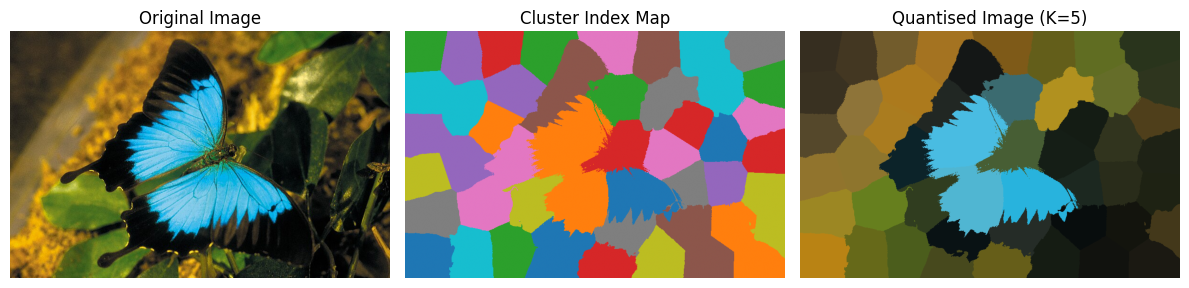

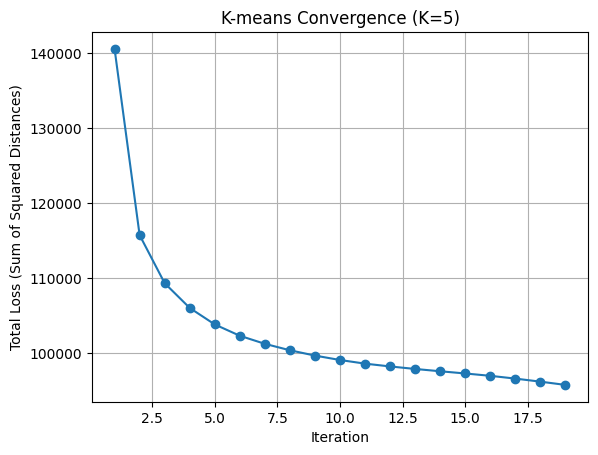

In [36]:
# Use your kmeans function to cluster based on colour and location
losses, cluster_idx_image, quantised_image = kmeans_superpixels(im, iters=20, K=50, plot=False)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(im[:, :, [2, 1, 0]])
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Cluster Index Map')
plt.imshow(cluster_idx_image, cmap='tab10')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Quantised Image (K=5)')
plt.imshow(quantised_image[:, :, [2, 1, 0]])
plt.axis('off')

plt.tight_layout()
plt.show()

plt.figure()
plt.plot(range(1, len(losses) + 1), losses, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Total Loss (Sum of Squared Distances)')
plt.title('K-means Convergence (K=5)')
plt.grid(True)
plt.show()


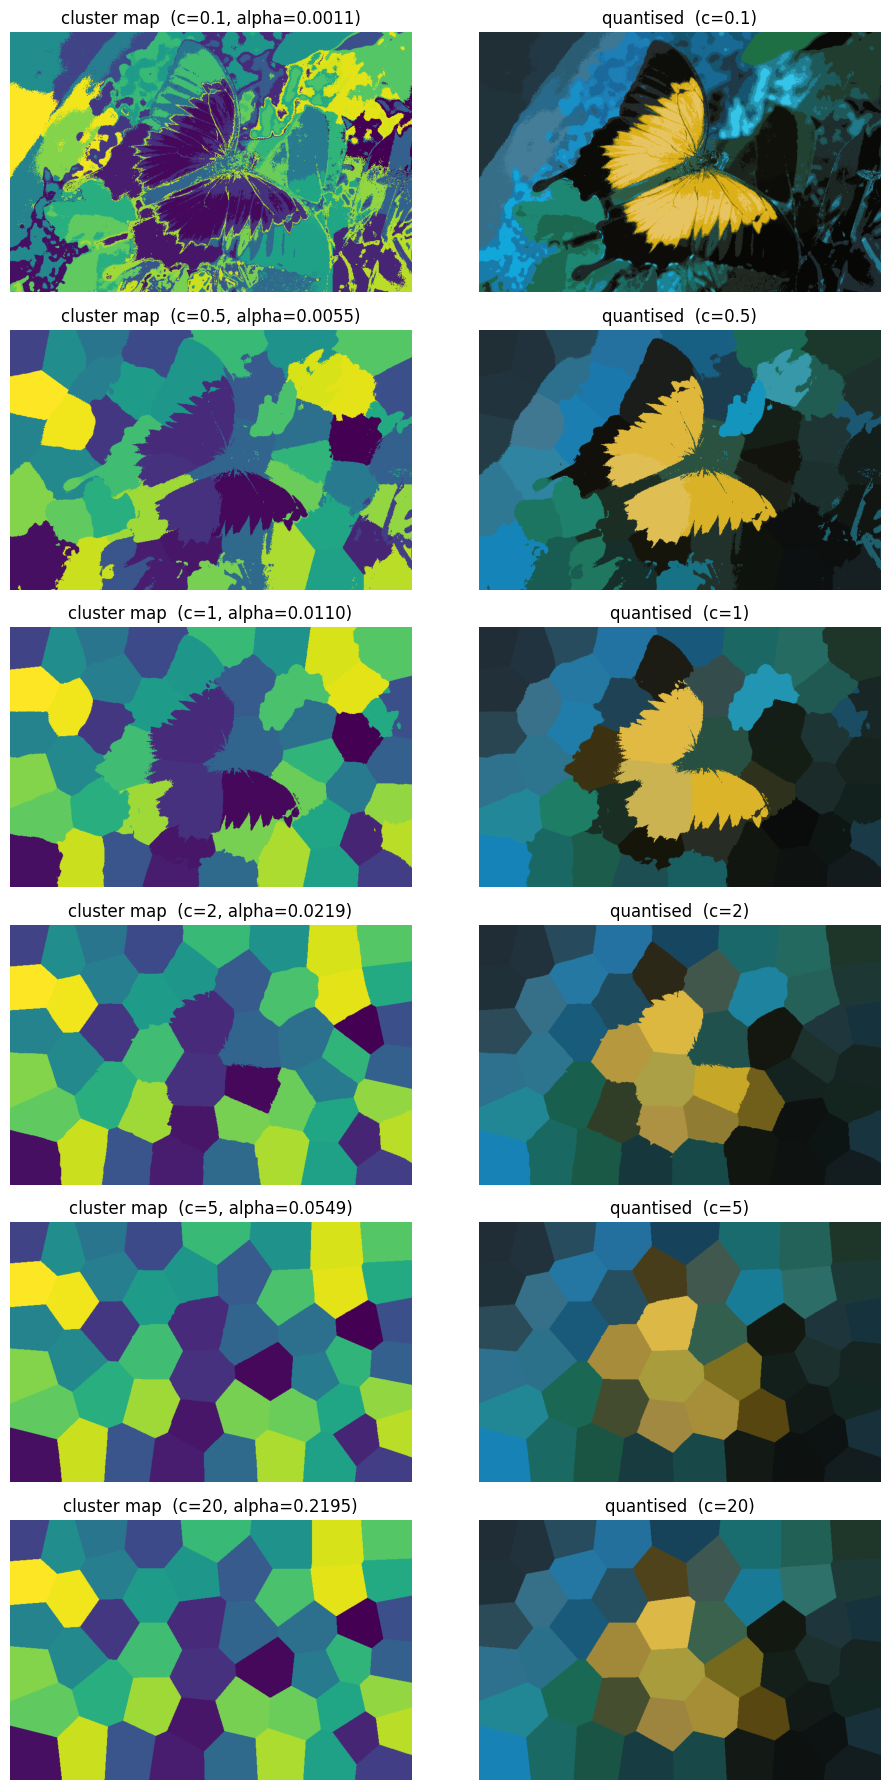

In [37]:
# Visualise your superpixel clustering for different scaling parameters 
K = 50
S = np.sqrt(im.shape[0] * im.shape[1] / K)
cs = [0.1, 0.5, 1, 2, 5, 20]

# plot cluster maps and quantised images for different scale values
fig, axes = plt.subplots(len(cs), 2, figsize=(10, 3 * len(cs)))
for row, c in enumerate(cs):
    alpha = c / S
    _, cluster_idx, quant = kmeans_superpixels(im, iters=10, K=K, alpha=alpha)

    axes[row, 0].imshow(cluster_idx)
    axes[row, 0].set_title(f'cluster map  (c={c}, alpha={alpha:.4f})')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(quant)
    axes[row, 1].set_title(f'quantised  (c={c})')
    axes[row, 1].axis('off')
plt.tight_layout()
plt.show()

## Task 3: Region proposal

Segment your image into 10 superpixels. Then find the locations of the top left pixel and bottom right pixel in a superpixel, and use this information and the cv2.rectangle function to draw rectangles (regions) on the original image for each superpixel.


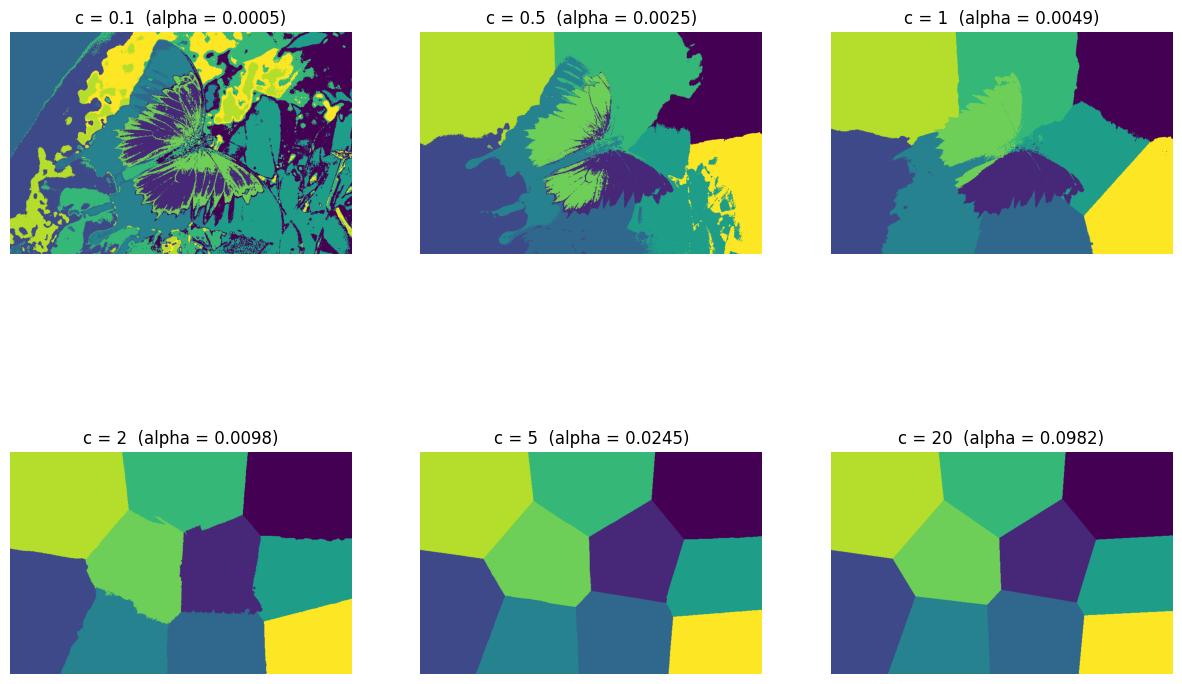

In [33]:
# Visualise your regions on the original image
K = 10
S = np.sqrt(im.shape[0] * im.shape[1] / K)
cs = [0.1, 0.5, 1, 2, 5, 20]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, c in zip(axes.flat, cs):
    alpha = c / S
    _, cluster_idx, quant = kmeans_superpixels(im, iters=10, K=K, alpha=alpha)
    ax.imshow(cluster_idx)
    ax.set_title(f'c = {c}  (alpha = {alpha:.4f})')
    ax.axis('off')
plt.show()

In [35]:
print(cluster_idx)
print(quant)

[[8 8 8 ... 0 0 0]
 [8 8 8 ... 0 0 0]
 [8 8 8 ... 0 0 0]
 ...
 [2 2 2 ... 9 9 9]
 [2 2 2 ... 9 9 9]
 [2 2 2 ... 9 9 9]]
[[[0.15746071 0.32057359 0.40182029]
  [0.15746071 0.32057359 0.40182029]
  [0.15746071 0.32057359 0.40182029]
  ...
  [0.13018202 0.3361594  0.31596211]
  [0.13018202 0.3361594  0.31596211]
  [0.13018202 0.3361594  0.31596211]]

 [[0.15746071 0.32057359 0.40182029]
  [0.15746071 0.32057359 0.40182029]
  [0.15746071 0.32057359 0.40182029]
  ...
  [0.13018202 0.3361594  0.31596211]
  [0.13018202 0.3361594  0.31596211]
  [0.13018202 0.3361594  0.31596211]]

 [[0.15746071 0.32057359 0.40182029]
  [0.15746071 0.32057359 0.40182029]
  [0.15746071 0.32057359 0.40182029]
  ...
  [0.13018202 0.3361594  0.31596211]
  [0.13018202 0.3361594  0.31596211]
  [0.13018202 0.3361594  0.31596211]]

 ...

 [[0.13204981 0.47996802 0.56103347]
  [0.13204981 0.47996802 0.56103347]
  [0.13204981 0.47996802 0.56103347]
  ...
  [0.06382424 0.10143509 0.10643592]
  [0.06382424 0.10143509 0.106

Text(0.5, 1.0, 'Original Image with Superpixel Boundaries')

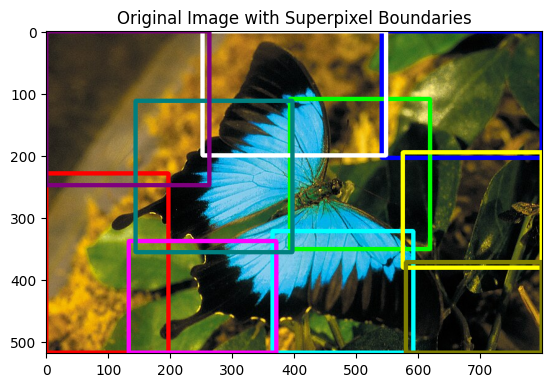

In [ ]:
# for each superpixel find the top left and bottom right pixel coordinates, use cv2.rectangle to highlight the original image where the superpixel is located
colours = np.unique(quant.reshape(-1, 3), axis=0)
im_regions = im.copy()
for k in range(K):
    mask = cluster_idx == k
    ys, xs = np.where(mask)
    if len(ys) > 0 and len(xs) > 0:
        top_left = (xs.min(), ys.min())
        bottom_right = (xs.max(), ys.max())
        # use different colour for each superpixel
        cv2.rectangle(im_regions, top_left, bottom_right, colours[k % len(colours)], 5)
plt.imshow(im_regions[:, :, [2, 1, 0]])
plt.title('Original Image with Superpixel Boundaries')

## Task 4: Discussion

Write a brief report (max 600 words) discussing explaining your implementation
and results. Explain your reasoning by referencing the intermediate result figures
you generated.
